In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
users = pd.read_csv("users.csv")
orders = pd.read_csv("orders.csv")
events = pd.read_csv("events.csv")

users.head(), orders.head(), events.head()

(   user_id signup_date country   device
 0        1  2026-04-13      US  desktop
 1        2  2026-06-29   China   mobile
 2        3  2026-04-03  Canada   mobile
 3        4  2026-01-15      US  desktop
 4        5  2026-04-17  Mexico  desktop,
    order_id  user_id  order_date  amount     status
 0         1      983  2026-04-09   84.66  completed
 1         2      729  2026-04-12    0.96  completed
 2         3      504  2026-03-22   66.57  completed
 3         4      456  2026-03-20   11.68  completed
 4         5       45  2026-03-08    7.13  cancelled,
    event_id  user_id  event_date    event_type traffic_source
 0         1        4  2026-04-21  view_product    paid_search
 1         2      854  2026-03-23   add_to_cart         social
 2         3      640  2026-04-04  view_product         social
 3         4      986  2026-05-06      purchase        organic
 4         5      992  2026-04-03      checkout    paid_search)

In [4]:
print(users.shape)
print(orders.shape)
print(events.shape)

display(users.head())
display(orders.head())
display(events.head())

(1000, 4)
(1500, 5)
(5000, 5)


,user_id,signup_date,country,device
0,1,2026-04-13,US,desktop
1,2,2026-06-29,China,mobile
2,3,2026-04-03,Canada,mobile
3,4,2026-01-15,US,desktop
4,5,2026-04-17,Mexico,desktop


,order_id,user_id,order_date,amount,status
0,1,983,2026-04-09,84.66,completed
1,2,729,2026-04-12,0.96,completed
2,3,504,2026-03-22,66.57,completed
3,4,456,2026-03-20,11.68,completed
4,5,45,2026-03-08,7.13,cancelled


,event_id,user_id,event_date,event_type,traffic_source
0,1,4,2026-04-21,view_product,paid_search
1,2,854,2026-03-23,add_to_cart,social
2,3,640,2026-04-04,view_product,social
3,4,986,2026-05-06,purchase,organic
4,5,992,2026-04-03,checkout,paid_search


In [5]:
users["signup_date"] = pd.to_datetime(users["signup_date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])
events["event_date"] = pd.to_datetime(events["event_date"])

1. Calculate Daily Active Users

In [6]:
dau = (
    events.groupby("event_date")["user_id"].nunique().reset_index(name="dau").sort_values("event_date")
)

In [7]:
dau.head()

,event_date,dau
0,2026-03-01,54
1,2026-03-02,48
2,2026-03-03,56
3,2026-03-04,53
4,2026-03-05,48


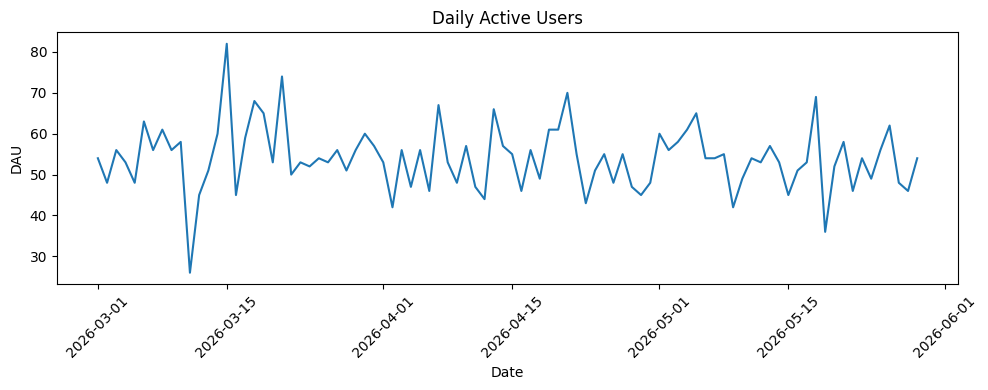

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(dau["event_date"], dau["dau"])
plt.title("Daily Active Users")
plt.xlabel("Date")
plt.ylabel("DAU")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. Calculate Daily GMV

In [10]:
daily_gmv = (
    orders[orders["status"] == "completed"].groupby("order_date").agg(
        completed_order_count = ("order_id", "count"),
        daily_gmv = ("amount", "sum")).reset_index().sort_values("order_date")
)

In [11]:
daily_gmv.head()

,order_date,completed_order_count,daily_gmv
0,2026-03-01,15,666.29
1,2026-03-02,11,419.79
2,2026-03-03,9,344.68
3,2026-03-04,19,1094.89
4,2026-03-05,8,338.66


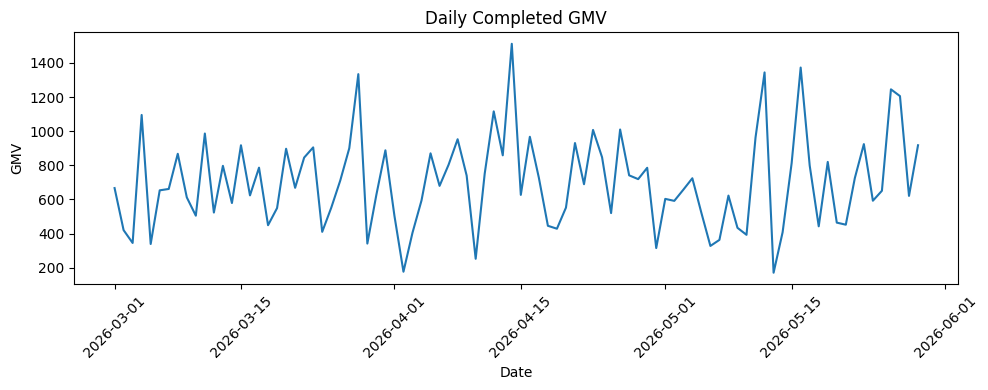

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(daily_gmv["order_date"], daily_gmv["daily_gmv"])
plt.title("Daily Completed GMV")
plt.xlabel("Date")
plt.ylabel("GMV")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3. Calculate Average Order Value

In [13]:
daily_gmv["aov"] = daily_gmv["daily_gmv"] / daily_gmv["completed_order_count"]

In [14]:
daily_gmv.head()

,order_date,completed_order_count,daily_gmv,aov
0,2026-03-01,15,666.29,44.419333
1,2026-03-02,11,419.79,38.162727
2,2026-03-03,9,344.68,38.297778
3,2026-03-04,19,1094.89,57.625789
4,2026-03-05,8,338.66,42.332500


4. Calculate Daily Conversion Rate

In [15]:
view_users = (
    events[events["event_type"] == "view_product"]
    .groupby("event_date")["user_id"]
    .nunique()
    .reset_index(name="view_users")
)

purchase_users = (
    events[events["event_type"] == "purchase"]
    .groupby("event_date")["user_id"]
    .nunique()
    .reset_index(name="purchase_users")
)

daily_conversion = view_users.merge(purchase_users, on="event_date", how="left")
daily_conversion["purchase_users"] = daily_conversion["purchase_users"].fillna(0)

daily_conversion["purchase_conversion_rate"] = (
    daily_conversion["purchase_users"] / daily_conversion["view_users"].replace(0, np.nan)
)

daily_conversion.head()

,event_date,view_users,purchase_users,purchase_conversion_rate
0,2026-03-01,31,3,0.096774
1,2026-03-02,25,3,0.120000
2,2026-03-03,32,6,0.187500
3,2026-03-04,30,8,0.266667
4,2026-03-05,29,2,0.068966


5. Calculate Average Revenue Per User

In [16]:
daily_arpu = dau.merge(
    daily_gmv[["order_date", "daily_gmv"]],
    left_on="event_date",
    right_on="order_date",
    how="left"
)

daily_arpu["daily_gmv"] = daily_arpu["daily_gmv"].fillna(0)
daily_arpu["arpu"] = daily_arpu["daily_gmv"] / daily_arpu["dau"]

daily_arpu.head()

,event_date,dau,order_date,daily_gmv,arpu
0,2026-03-01,54,2026-03-01,666.29,12.338704
1,2026-03-02,48,2026-03-02,419.79,8.745625
2,2026-03-03,56,2026-03-03,344.68,6.155000
3,2026-03-04,53,2026-03-04,1094.89,20.658302
4,2026-03-05,48,2026-03-05,338.66,7.055417


6. Conversion Rate Regarding Traffic Sources

In [17]:
source_view = (
    events[events["event_type"] == "view_product"]
    .groupby("traffic_source")["user_id"]
    .nunique()
    .reset_index(name="view_users")
)

source_purchase = (
    events[events["event_type"] == "purchase"]
    .groupby("traffic_source")["user_id"]
    .nunique()
    .reset_index(name="purchase_users")
)

source_conversion = source_view.merge(source_purchase, on="traffic_source", how="left")
source_conversion["purchase_users"] = source_conversion["purchase_users"].fillna(0)
source_conversion["purchase_conversion_rate"] = (
    source_conversion["purchase_users"] / source_conversion["view_users"].replace(0, np.nan)
)

source_conversion.sort_values("purchase_conversion_rate", ascending=False)

,traffic_source,view_users,purchase_users,purchase_conversion_rate
3,social,505,113,0.223762
0,email,538,112,0.208178
2,paid_search,485,89,0.183505
1,organic,498,73,0.146586


7. Order Performance Regarding Devices

In [18]:
orders_with_users = orders.merge(users, on="user_id", how="left")

device_order_perf = (
    orders_with_users[orders_with_users["status"] == "completed"]
    .groupby("device")
    .agg(
        completed_order_count=("order_id", "count"),
        total_gmv=("amount", "sum"),
        purchasing_users=("user_id", "nunique")
    )
    .reset_index()
)

device_order_perf["aov"] = (
    device_order_perf["total_gmv"] / device_order_perf["completed_order_count"]
)

device_order_perf.sort_values("total_gmv", ascending=False)

,device,completed_order_count,total_gmv,purchasing_users,aov
1,mobile,778,39379.19,436,50.615925
0,desktop,435,21634.50,256,49.734483
2,tablet,62,2116.30,29,34.133871


8. Repeat Purchase Rate

In [21]:
user_orders = (
    orders[orders["status"] == "completed"]
    .groupby("user_id")
    .agg(completed_order_count=("order_id", "count"))
    .reset_index()
)

purchasing_users = user_orders["user_id"].nunique()
repeat_purchase_users = user_orders[user_orders["completed_order_count"] >= 2]["user_id"].nunique()
repeat_purchase_rate = repeat_purchase_users / purchasing_users

purchasing_users, repeat_purchase_users, repeat_purchase_rate

(721, 362, 0.5020804438280166)

## Key Findings

1. Daily active users fluctuated across the observation period, suggesting uneven user engagement.
2. Completed GMV showed day-to-day variation, which may reflect differences in purchase behavior or traffic quality.
3. Purchase conversion rate varied by traffic source, indicating that acquisition channels may differ in user intent.
4. Device-level order performance showed differences in GMV and AOV, which can inform device-specific product optimization.
5. Repeat purchase rate provides a directional signal of customer loyalty and can be further analyzed by cohort.